
# Diffusion Watermarking with **Pretrained** Weights (Hugging Face)

This notebook avoids long training by starting from a **pretrained DDPM** and then doing a **short fine-tune** to embed a watermark in the **intermediate diffusion step** \(t_A\).

**What you'll run:**
1. **Baseline (pretrained)** — Load `google/ddpm-cifar10-32` via `diffusers`, sample images.
2. **Watermarked (fine-tuned)** — Fine-tune the pretrained UNet for a **small number of steps** with the watermark objective (fast), then sample.
3. **Verify** — Capture states at \(t_A\), average them, and perform a simple contour match to detect the watermark.



## Setup
Uncomment installs if running in a fresh environment.


In [1]:

# !pip install --upgrade diffusers>=0.28.0 transformers accelerate safetensors
# !pip install torch torchvision torchaudio  # choose the right CUDA wheel for your machine
# !pip install matplotlib opencv-python tqdm

import math, os, numpy as np
import torch, torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

from diffusers import DDPMPipeline, DDPMScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torch\onnx\_internal\_beartype.py:36: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


Device: cuda


## Config

In [2]:

from dataclasses import dataclass

@dataclass
class Config:
    # Pretrained model on CIFAR-10 (32x32)
    model_id: str = "google/ddpm-cifar10-32"
    image_size: int = 32
    channels: int = 3

    # Sampling
    n_final_samples: int = 36
    num_inference_steps: int = 250  # fewer than training's 1000 for speed

    # Watermark
    gamma: float = 0.8          # blend factor for embedding objective
    tA_frac: float = 0.75       # later for CIFAR-10
    wtmk_shape: str = "square"  # "square" | "x"
    wtmk_pos: str = "bottom_right"  # "bottom_right" | "center"
    wtmk_size: int = 8
    wtmk_margin: int = 2

    # Fast fine-tuning params
    subset_size: int = 5000     # use a small subset for speed
    batch_size: int = 128
    lr: float = 2e-4
    max_steps: int = 300        # keep small; adjust as needed

    # Verification
    verify_batches: int = 8
    verify_batch_size: int = 64

cfg = Config()
print(cfg)


Config(model_id='google/ddpm-cifar10-32', image_size=32, channels=3, n_final_samples=36, num_inference_steps=250, gamma=0.8, tA_frac=0.75, wtmk_shape='square', wtmk_pos='bottom_right', wtmk_size=8, wtmk_margin=2, subset_size=5000, batch_size=128, lr=0.0002, max_steps=300, verify_batches=8, verify_batch_size=64)


## Load Pretrained Pipeline

In [3]:

pipe = DDPMPipeline.from_pretrained(cfg.model_id)
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=False)

# Grab references to the underlying UNet and scheduler
unet = pipe.unet
scheduler: DDPMScheduler = pipe.scheduler

# Ensure scheduler is in training-compatible configuration
num_train_timesteps = scheduler.config.num_train_timesteps
alphas_cumprod = scheduler.alphas_cumprod.to(device)  # shape [T], T≈1000 by default
print("Scheduler timesteps:", num_train_timesteps)


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Scheduler timesteps: 1000


## Visualization Helper

In [4]:

def show_grid_from_pil(pil_images, title=""):
    # Build a grid from a list of PIL images
    import numpy as np
    import matplotlib.pyplot as plt
    n = len(pil_images)
    nrow = int(math.sqrt(n))
    ncol = (n + nrow - 1) // nrow
    plt.figure(figsize=(6,6))
    w, h = pil_images[0].size
    grid = np.zeros((h*nrow, w*ncol, 3), dtype=np.uint8)
    for idx, im in enumerate(pil_images):
        r = idx // ncol
        c = idx % ncol
        grid[r*h:(r+1)*h, c*w:(c+1)*w] = np.array(im.convert("RGB"))
    plt.imshow(grid); plt.axis("off"); plt.title(title); plt.show()

def show_grid_tensor(imgs, title=""):
    # imgs: [N,C,H,W] in [0,1] float tensor
    grid = make_grid(imgs, nrow=int(math.sqrt(len(imgs))), padding=2)
    npimg = (grid.detach().cpu().permute(1,2,0).numpy()*255).astype(np.uint8)
    plt.figure(figsize=(6,6))
    plt.imshow(npimg); plt.axis("off"); plt.title(title); plt.show()


# Part 1 — Baseline (Pretrained)

  0%|          | 0/250 [00:00<?, ?it/s]

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\diffusers\models\attention_processor.py:2383: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(


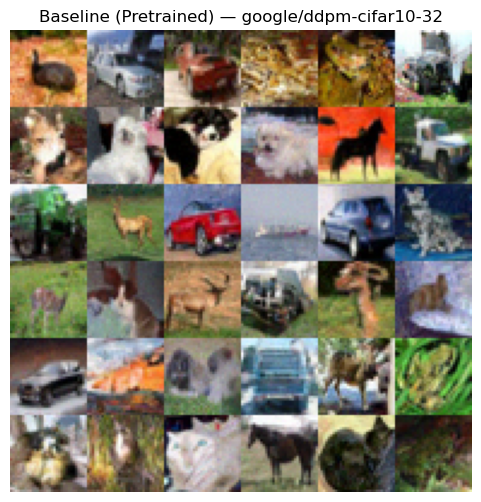

In [5]:

# Sample directly from the pretrained pipeline (fast)
out = pipe(batch_size=cfg.n_final_samples, num_inference_steps=cfg.num_inference_steps)
baseline_images = out.images  # list of PIL images
show_grid_from_pil(baseline_images, f"Baseline (Pretrained) — {cfg.model_id}")


## Tiny CIFAR-10 Subset for Fast Fine-Tuning

In [6]:

transform = transforms.Compose([
    transforms.Resize(cfg.image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),  # scale to [-1,1]
])
trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
idx = np.random.choice(len(trainset), size=min(cfg.subset_size, len(trainset)), replace=False)
subset = Subset(trainset, idx)
train_loader = DataLoader(subset, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)
print("Train batches:", len(train_loader))


Files already downloaded and verified
Train batches: 40


## Watermark Mask

In [7]:

def make_watermark_mask(H, W, shape="square", pos="bottom_right", size=8, margin=2, channels=3):
    mask = np.zeros((H, W), dtype=np.float32)
    if shape == "square":
        if pos == "bottom_right":
            r0 = H - margin - size; c0 = W - margin - size
        else:  # center
            r0 = H//2 - size//2; c0 = W//2 - size//2
        mask[r0:r0+size, c0:c0+size] = 1.0
    elif shape == "x":
        thickness = max(1, size//4)
        if pos == "bottom_right":
            r0 = H - margin - size; c0 = W - margin - size
        else:
            r0 = H//2 - size//2; c0 = W//2 - size//2
        for k in range(size):
            rr, cc = r0 + k, c0 + k
            mask[max(0, rr-thickness):min(H, rr+thickness+1), max(0, cc-thickness):min(W, cc+thickness+1)] = 1.0
            rr2, cc2 = r0 + k, c0 + (size-1-k)
            mask[max(0, rr2-thickness):min(H, rr2+thickness+1), max(0, cc2-thickness):min(W, cc2+thickness+1)] = 1.0
    else:
        raise ValueError("Unknown shape")
    m = torch.from_numpy(mask).repeat(channels,1,1)  # C,H,W
    return m

H = W = cfg.image_size
wmask = make_watermark_mask(H, W, cfg.wtmk_shape, cfg.wtmk_pos, cfg.wtmk_size, cfg.wtmk_margin, cfg.channels).to(device)


# xA = (2.0*wmask - 1.0).to(device)  # watermark image in [-1,1] within the mask, 0 elsewhere
wtmk_strength = 1.0          # try 0.25–1.0
xA = (wmask * wtmk_strength).to(device)   # 1 in the square, 0 elsewhere
print("Watermark mask ready:", xA.shape)


Watermark mask ready: torch.Size([3, 32, 32])


# Part 2 — Fast Fine-Tune to Embed Watermark

In [8]:
unet.train()

# Freeze all, train only mid + last up block (keeps generative prior)
for p in unet.parameters(): 
    p.requires_grad = False
for p in unet.mid_block.parameters():
    p.requires_grad = True
for p in unet.up_blocks[-1].parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW(
    (p for p in unet.parameters() if p.requires_grad),
    lr=5e-5, weight_decay=0.01
)

# optimizer = torch.optim.AdamW(unet.parameters(), lr=cfg.lr)

T = scheduler.config.num_train_timesteps
tA = int(cfg.tA_frac * T)
alphas_cumprod = scheduler.alphas_cumprod.to(device)  # [T]

step = 0
pbar = tqdm(total=cfg.max_steps, desc="Watermark FT (pretrained init)")
data_iter = iter(train_loader)

while step < cfg.max_steps:
    try:
        x0, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        x0, _ = next(data_iter)

    x0 = x0.to(device)  # [-1,1]
    bsz = x0.size(0)

    # Random timesteps
    t = torch.randint(0, T, (bsz,), device=device, dtype=torch.long)

    # Standard forward sample using diffusers helper
    eps_prime = torch.randn_like(x0)
    x_sim = scheduler.add_noise(x0, eps_prime, t)  # sqrt(a_bar)*x0 + sqrt(1-a_bar)*eps'

    # Ramp f2(t) from 0..1 over [0..tA]
    f2_t = torch.clamp(t.float() / max(1, tA), 0.0, 1.0).view(-1,1,1,1)
    bt = f2_t * xA  # broadcast

    # Build x'_t and epsilon''
    a_bar_t = alphas_cumprod[t].view(-1,1,1,1)
    x_t_prime = (a_bar_t.sqrt() * x0) + cfg.gamma * (1 - a_bar_t).sqrt() * eps_prime + (1 - cfg.gamma) * bt
    eps_dblprime = cfg.gamma * eps_prime + (1 - cfg.gamma) * xA

    # For t > tA, revert to standard q_sample (simulation stage)
    sim_mask = (t > tA)
    if sim_mask.any():
        idx = sim_mask.nonzero(as_tuple=False).squeeze(1)
        x_t_prime[idx] = x_sim[idx]
        eps_dblprime[idx] = eps_prime[idx]

    # Predict noise with UNet
    noise_pred = unet(x_t_prime, t, return_dict=False)[0]
    loss = F.mse_loss(noise_pred, eps_dblprime)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    step += 1
    pbar.set_postfix(loss=float(loss.detach().cpu()))
    pbar.update(1)

pbar.close()
unet.eval()


Watermark FT (pretrained init): 100%|██████████| 300/300 [01:15<00:00,  3.98it/s, loss=0.0177] 


UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(12

## Sampler (manual, using diffusers scheduler)

In [9]:

@torch.no_grad()
def sample_with_scheduler(unet, scheduler: DDPMScheduler, num_images=36, num_inference_steps=250, gamma_div=None, capture_tA=None):
    # Returns (final_imgs [N,C,H,W] in [0,1], x_at_tA [N,C,H,W] if capture_tA else None)
    unet.eval()
    scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = scheduler.timesteps  # e.g., [999, 998, ..., 0] length = num_inference_steps
    N = num_images
    C = cfg.channels
    H = W = cfg.image_size

    x = torch.randn(N, C, H, W, device=device)
    x_tA = None

    # Map capture_tA in [0..T-1] to nearest in 'timesteps'
    capture_idx = None
    if capture_tA is not None:
        diffs = (timesteps.to(torch.long) - int(capture_tA)).abs()
        capture_idx = int(torch.argmin(diffs).item())

    for i, t in enumerate(timesteps):
        model_out = unet(x, t, return_dict=False)[0]
        step_out = scheduler.step(model_out, t, x, return_dict=True)
        x = step_out.prev_sample

        if capture_idx is not None and i == capture_idx:
            x_tA = x.clone()

    if gamma_div:
        x = x / gamma_div
        if x_tA is not None:
            x_tA = x_tA / gamma_div
    imgs = ((x.clamp(-1,1) + 1) * 0.5).detach()
    if x_tA is not None:
        x_tA = ((x_tA.clamp(-1,1) + 1) * 0.5).detach()
    return imgs, x_tA


## Sampling — Baseline vs Watermarked

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


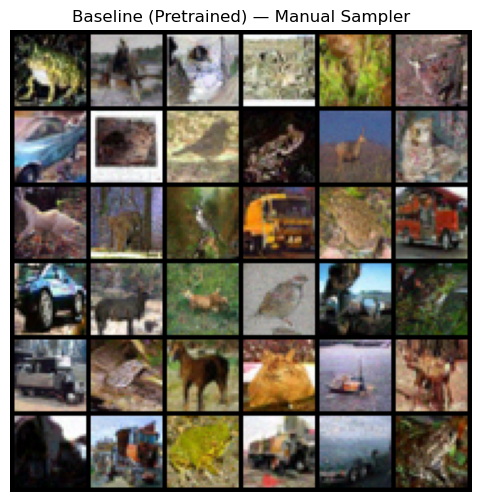

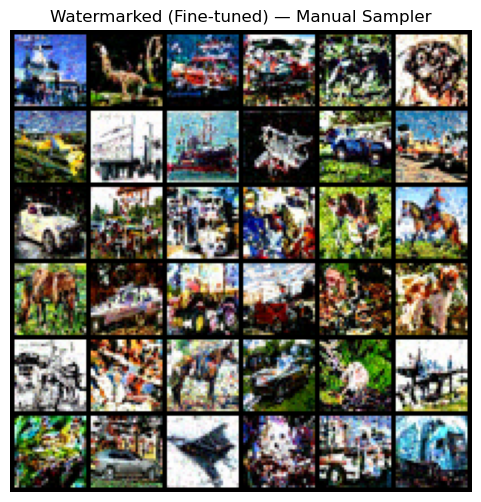

In [10]:
# Baseline again (via manual sampler): reload fresh weights for a clean baseline UNet
baseline_pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
baseline_unet = baseline_pipe.unet
baseline_sched: DDPMScheduler = baseline_pipe.scheduler

imgs_base, _ = sample_with_scheduler(
    baseline_unet,
    baseline_sched,
    num_images=cfg.n_final_samples,
    num_inference_steps=cfg.num_inference_steps,
)
show_grid_tensor(imgs_base, "Baseline (Pretrained) — Manual Sampler")

# Watermarked (fine-tuned UNet we trained above)
tA = int(cfg.tA_frac * scheduler.config.num_train_timesteps)
imgs_wtmk, x_tA = sample_with_scheduler(
    unet,
    scheduler,
    num_images=cfg.n_final_samples,
    num_inference_steps=cfg.num_inference_steps,
    # gamma_div=cfg.gamma,
    gamma_div=None,
    capture_tA=tA,
)
show_grid_tensor(imgs_wtmk, "Watermarked (Fine-tuned) — Manual Sampler")

# Verification — Detect Watermark at $t_A$

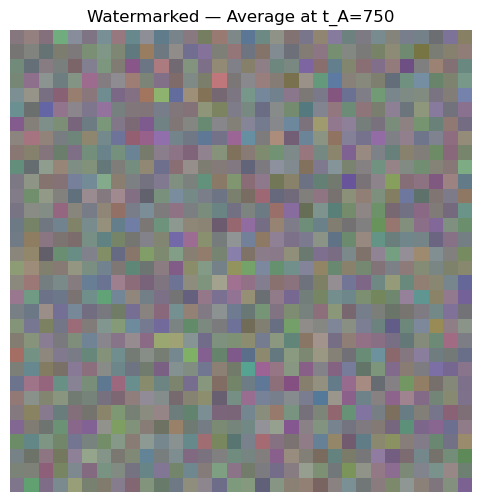

Verifying: 100%|██████████| 8/8 [01:19<00:00,  9.93s/it]

Contour distances per batch: [1.e+09 1.e+09 1.e+09 1.e+09 1.e+09 1.e+09 1.e+09 1.e+09]
Detection success (fraction below threshold): 0.00


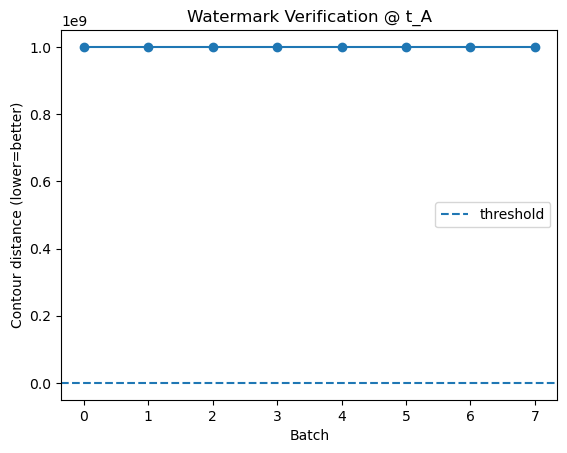

In [11]:

def tensor_to_uint8(img):
    # img: [N,C,H,W] in [0,1]
    img = (img.clamp(0,1) * 255).to(torch.uint8).detach().cpu()
    return img

def make_pattern_image_like(mask, value=255):
    m = mask  # [C,H,W]
    # collapse to single channel for shape detection
    m1 = (m[0] > 0).to(torch.uint8).cpu().numpy() * value
    return m1

def contour_similarity(img_u8, pattern_u8):
    # Expects single channel (H,W) uint8
    img_blur = cv2.GaussianBlur(img_u8, (3,3), 0)
    pat_blur = cv2.GaussianBlur(pattern_u8, (3,3), 0)
    img_edges = cv2.Canny(img_blur, 50, 150)
    pat_edges = cv2.Canny(pat_blur, 50, 150)
    contours_img, _ = cv2.findContours(img_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_pat, _ = cv2.findContours(pat_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours_img) == 0 or len(contours_pat) == 0:
        return 1e9
    best = 1e9
    for ci in contours_img:
        for cp in contours_pat:
            d = cv2.matchShapes(ci, cp, cv2.CONTOURS_MATCH_I1, 0.0)
            if d < best:
                best = d
    return best

@torch.no_grad()
def verify_watermark(unet, scheduler, batches=8, batch_size=64, tA=None, mask=None, gamma_div=None, threshold=0.3):
    if tA is None:
        tA = int(cfg.tA_frac * scheduler.config.num_train_timesteps)
    if mask is None:
        mask = wmask
    pattern_u8 = make_pattern_image_like(mask, value=255)
    dists = []
    for _ in tqdm(range(batches), desc="Verifying"):
        _, xA_mid = sample_with_scheduler(unet, scheduler, num_images=batch_size, num_inference_steps=cfg.num_inference_steps,
                                          gamma_div=gamma_div, capture_tA=tA)
        xavg = xA_mid.mean(dim=0, keepdim=True)  # [1,C,H,W]
        # use first channel
        xavg_u8 = tensor_to_uint8(xavg)[0,0].numpy()
        d = contour_similarity(xavg_u8, pattern_u8)
        dists.append(d)
    arr = np.array(dists, dtype=np.float32)
    success = float((arr < threshold).mean())
    return arr, success

# Visualize the average at t_A for one batch
if x_tA is None:
    # if not captured previously, capture now
    _, x_tA = sample_with_scheduler(unet, scheduler, num_images=cfg.verify_batch_size, num_inference_steps=cfg.num_inference_steps,
                                    gamma_div=cfg.gamma, capture_tA=tA)
xavg = x_tA.mean(dim=0, keepdim=True)
show_grid_tensor(xavg, f"Watermarked — Average at t_A={tA}")

# Compute distances across several batches
distances, success = verify_watermark(unet, scheduler, batches=cfg.verify_batches, batch_size=cfg.verify_batch_size,
                                      tA=tA, mask=wmask, gamma_div=cfg.gamma, threshold=0.3)
print("Contour distances per batch:", distances)
print(f"Detection success (fraction below threshold): {success:.2f}")

plt.figure()
plt.plot(np.arange(len(distances)), distances, marker='o')
plt.axhline(0.3, linestyle='--', label='threshold')
plt.xlabel("Batch"); plt.ylabel("Contour distance (lower=better)")
plt.title("Watermark Verification @ t_A")
plt.legend(); plt.show()



## Notes & Tips
- Pretrained baseline is instant; watermark **fine-tuning** here is kept very short (≈ a few minutes on GPU for CIFAR‑10).
- For stronger watermark detection (lower contour distance), increase `max_steps` or tweak `gamma`, `tA_frac`, and the mask size.
- You can switch to other unconditional pretrained DDPMs by changing `cfg.model_id` and adjusting data accordingly.
